# Punto 3: Estrategia de Segmentación de Clientes

**Objetivo:** Diseñar y ejecutar una segmentación que permita a marketing distinguir claramente a los clientes fieles de los compradores esporádicos y priorizar intervenciones ante riesgo de abandono.

## Realidad Crítica de los Datos

**El 97% de los clientes ha realizado una sola compra.** Un RFM clásico colapsaría a la mayoría de los clientes en un solo grupo, por lo que necesitamos señales basadas en comportamiento para separar valor, propensión a la lealtad y riesgo de servicio.

## Nuestro Enfoque: Segmentación Conductual + Capa de Riesgo

1. **Clustering conductual para estrategia de marketing**: Construir segmentos con RFM enriquecido + variables de comportamiento del cliente.
2. **Capa de riesgo de servicio (capa separada)**: Rastrear indicadores de riesgo (entrega tardía, puntaje de reseña bajo) sin permitir que dominen la segmentación de lealtad.
3. **Traducción de negocio**: Convertir los clusters técnicos en playbooks por segmento (retener, crecer, recuperar, reactivar).

### Por qué K-Means sobre otras alternativas

Consideramos DBSCAN y Modelos de Mezcla Gaussiana (GMM) como alternativas. DBSCAN requiere estructuras de vecindad basadas en densidad significativas, pero nuestros datos — dominados por un 97% de clientes con una sola compra — crean un núcleo denso masivo con valores atípicos dispersos en lugar de regiones de densidad naturalmente separables, haciendo que el ajuste de epsilon/min-samples sea arbitrario. GMM asume que los datos pueden modelarse como una mezcla de Gaussianas; aunque es más flexible que K-Means, produjo asignaciones de clusters similares con complejidad adicional (estimación de covarianza) y tiempos de convergencia más largos, sin ofrecer mejora práctica para la estructura de estos datos. K-Means, con variables estandarizadas y transformación logarítmica para señales sesgadas, proporciona una separación limpia basada en centroides que se traduce directamente en perfiles de segmento accionables — el requisito principal del negocio.

**Supuestos:**
- Solo se analizan pedidos entregados.
- `customer_unique_id` representa la identidad del cliente.
- Fecha de referencia para recencia = última compra en el dataset + 1 día (`2018-08-30`).

---
## 1. Configuración y Carga de Datos

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#0033a0', 'secondary': '#e3e82a', 'accent': '#6699cc',
    'danger': '#d0d0d0', 'neutral': '#0033a0'
}

DATA_PATH = '../Dataset_prueba/'

customers = pd.read_csv(f'{DATA_PATH}customers_dataset.csv')
orders = pd.read_csv(f'{DATA_PATH}orders_dataset.csv')
order_items = pd.read_csv(f'{DATA_PATH}order_items_dataset.csv')
order_payments = pd.read_csv(f'{DATA_PATH}order_payments_dataset.csv')
reviews = pd.read_csv(f'{DATA_PATH}order_reviews_dataset.csv')
products = pd.read_csv(f'{DATA_PATH}products_dataset.csv')
categories = pd.read_csv(f'{DATA_PATH}product_category_name_translation.csv')

# Parsear fechas
for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col])

# Filtrar a entregados y unir identidad del cliente
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered = delivered.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')


REFERENCE_DATE = delivered['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Delivered orders: {len(delivered):,}')
print(f'Unique customers: {delivered["customer_unique_id"].nunique():,}')
print(f'Reference date: {REFERENCE_DATE:%Y-%m-%d}')

Delivered orders: 96,478
Unique customers: 93,358
Reference date: 2018-08-30


---
## 2. Ingeniería de Variables — Construcción del Perfil 360° del Cliente

Calculamos **12 variables candidatas** en 4 dimensiones conductuales, y luego seleccionamos las más informativas mediante análisis de correlación y varianza (Sección 3).

| Dimensión | Variables | Justificación |
|---|---|---|
| **RFM Base** | Recencia, Frecuencia, Monetario, Antigüedad | Métricas estándar de comportamiento de compra |
| **Satisfacción** | Puntaje promedio de reseña, dejó comentario (S/N) | Proxy de engagement y sentimiento |
| **Pago** | Promedio de cuotas, uso de tarjeta de crédito | Sofisticación financiera, nivel de compromiso |
| **Experiencia** | Entrega tardía (S/N), ítems por pedido, categorías compradas | Experiencia operativa, complejidad del carrito |

In [36]:
# --- Features RFM ---
rfm = delivered.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (REFERENCE_DATE - x.max()).days),
    frequency=('order_id', 'nunique'),
    first_purchase=('order_purchase_timestamp', 'min'),
    last_purchase=('order_purchase_timestamp', 'max')
)

# Antigüedad del cliente (días desde primera compra)
rfm['tenure_days'] = (REFERENCE_DATE - rfm['first_purchase']).dt.days

# --- Features Monetarias ---
items_merged = order_items.merge(delivered[['order_id', 'customer_unique_id']], on='order_id')
monetary = items_merged.groupby('customer_unique_id').agg(
    monetary=('price', 'sum'),
    avg_item_price=('price', 'mean'),
    total_items=('order_item_id', 'count'),
    total_freight=('freight_value', 'sum')
)

# --- Diversidad de Productos ---
items_prods = items_merged.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
diversity = items_prods.groupby('customer_unique_id').agg(
    categories_bought=('product_category_name', 'nunique')
)

# --- Features de Pago ---
payments_merged = order_payments.merge(delivered[['order_id', 'customer_unique_id']], on='order_id')
payment_feats = payments_merged.groupby('customer_unique_id').agg(
    avg_installments=('payment_installments', 'mean'),
    uses_credit_card=('payment_type', lambda x: (x == 'credit_card').any().astype(int))
)

# --- Features de Satisfacción ---
reviews_merged = reviews.merge(delivered[['order_id', 'customer_unique_id']], on='order_id')
satisfaction = reviews_merged.groupby('customer_unique_id').agg(
    avg_review_score=('review_score', 'mean'),
    left_comment=('review_comment_message', lambda x: x.notna().any().astype(int))
)

# --- Experiencia de Entrega ---
delivered['delivery_delay'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered['was_late'] = (delivered['delivery_delay'] > 0).astype(int)
delivery_exp = delivered.groupby('customer_unique_id').agg(
    had_late_delivery=('was_late', 'max'),
    avg_delivery_delay=('delivery_delay', 'mean')
)

# --- Unir todas las features ---
customer_360 = (
    rfm[['recency', 'frequency', 'tenure_days']]
    .join(monetary[['monetary', 'avg_item_price', 'total_items']])
    .join(diversity)
    .join(payment_feats)
    .join(satisfaction)
    .join(delivery_exp)
)

# Rellenar nulos restantes
customer_360['avg_review_score'] = customer_360['avg_review_score'].fillna(customer_360['avg_review_score'].median())
customer_360 = customer_360.fillna(0)

print(f'Customer 360° table: {customer_360.shape[0]:,} customers × {customer_360.shape[1]} features')
print(f'\nFeature summary:')
customer_360.describe().round(2)

Customer 360° table: 93,358 customers × 13 features

Feature summary:


,recency,frequency,tenure_days,monetary,avg_item_price,total_items,categories_bought,avg_installments,uses_credit_card,avg_review_score,left_comment,had_late_delivery,avg_delivery_delay
count,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00,93358.00
mean,237.94,1.03,240.59,141.62,125.83,1.18,1.01,2.90,0.77,4.16,0.41,0.07,-11.85
std,152.59,0.21,153.10,215.69,190.53,0.62,0.20,2.68,0.42,1.28,0.49,0.25,10.14
min,1.00,1.00,1.00,0.85,0.85,1.00,0.00,0.00,0.00,1.00,0.00,0.00,-147.00
25%,114.00,1.00,117.00,47.65,42.90,1.00,1.00,1.00,1.00,4.00,0.00,0.00,-17.00
50%,219.00,1.00,222.00,89.73,79.00,1.00,1.00,2.00,1.00,5.00,0.00,0.00,-12.00
75%,346.00,1.00,350.00,154.74,139.90,1.00,1.00,4.00,1.00,5.00,1.00,0.00,-7.00
max,714.00,15.00,714.00,13440.00,6735.00,24.00,5.00,24.00,1.00,5.00,1.00,1.00,188.00


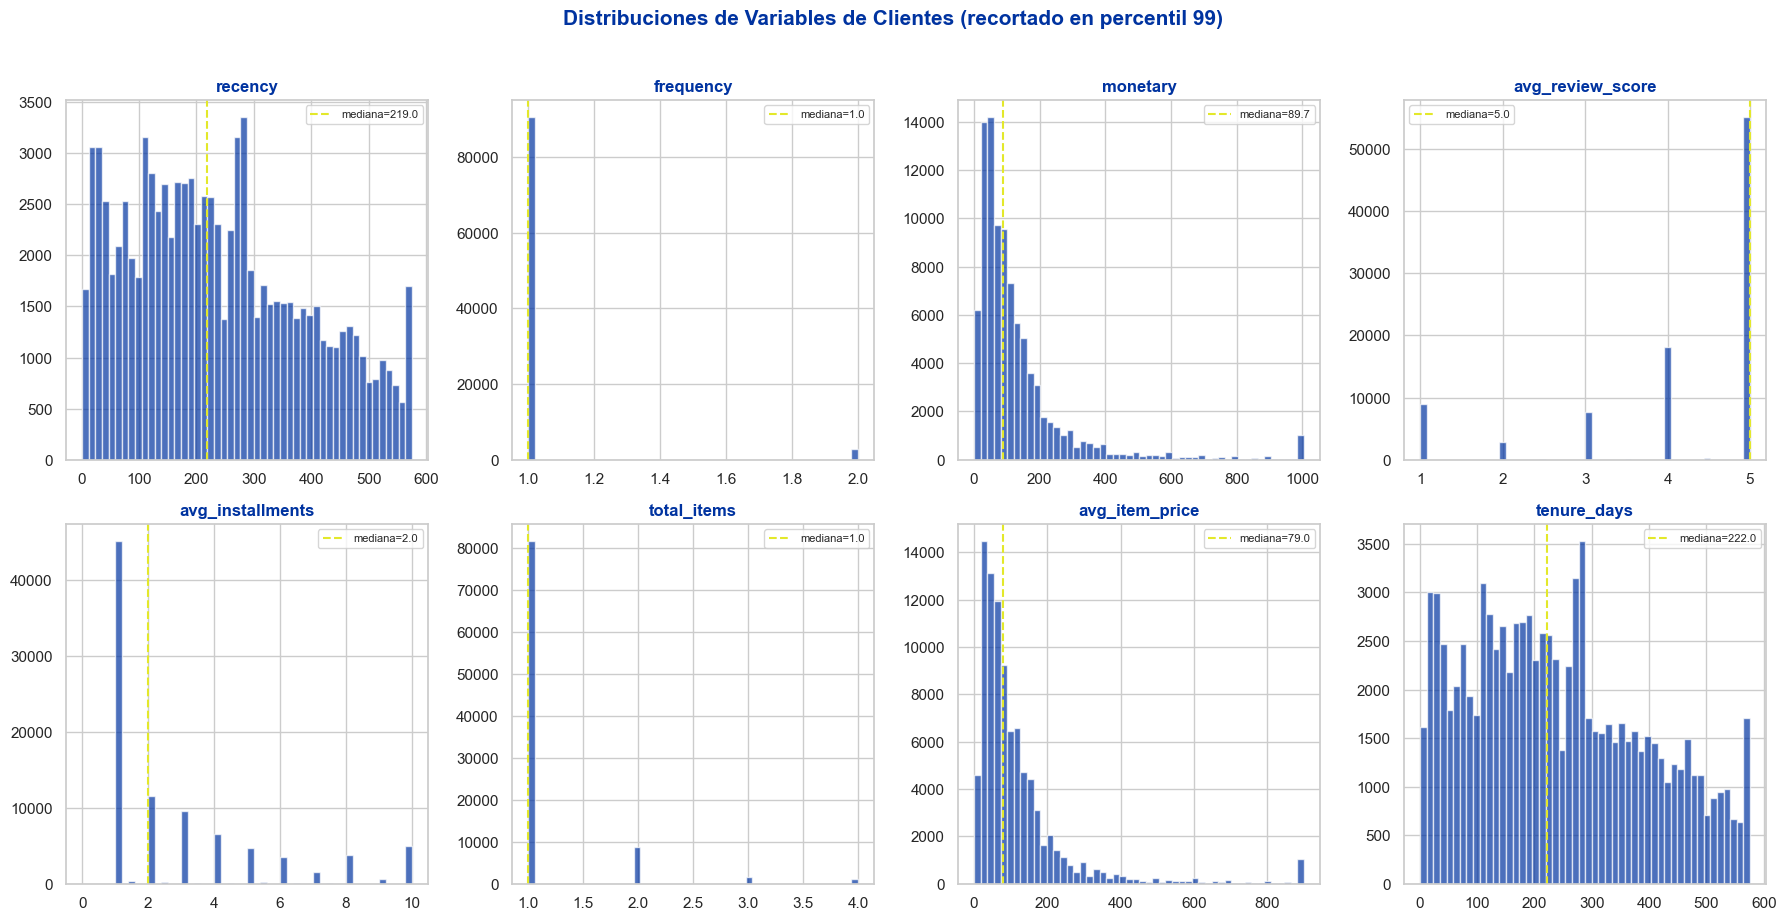

In [37]:
# --- Distribuciones de features ---
features_to_plot = ['recency', 'frequency', 'monetary', 'avg_review_score',
                     'avg_installments', 'total_items', 'avg_item_price', 'tenure_days']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.set_facecolor('white')
for ax, feat in zip(axes.flat, features_to_plot):
    data = customer_360[feat]
    # Recortar outliers extremos para visualización
    upper = data.quantile(0.99)
    ax.hist(data.clip(upper=upper), bins=50, color=COLORS['primary'], alpha=0.7, edgecolor='white')
    ax.set_title(feat, fontweight='bold', color='#0033a0')
    ax.axvline(data.median(), color=COLORS['secondary'], linestyle='--', label=f'mediana={data.median():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones de Variables de Clientes (recortado en percentil 99)',
             fontsize=15, fontweight='bold', y=1.02, color='#0033a0')
plt.tight_layout()
plt.savefig('../outputs/03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Selección de Variables y Escalado para Clustering

Antes del clustering, validamos que nuestras variables no sean redundantes (alta correlación = conteo doble de la misma señal) y que cada una contribuya varianza significativa.

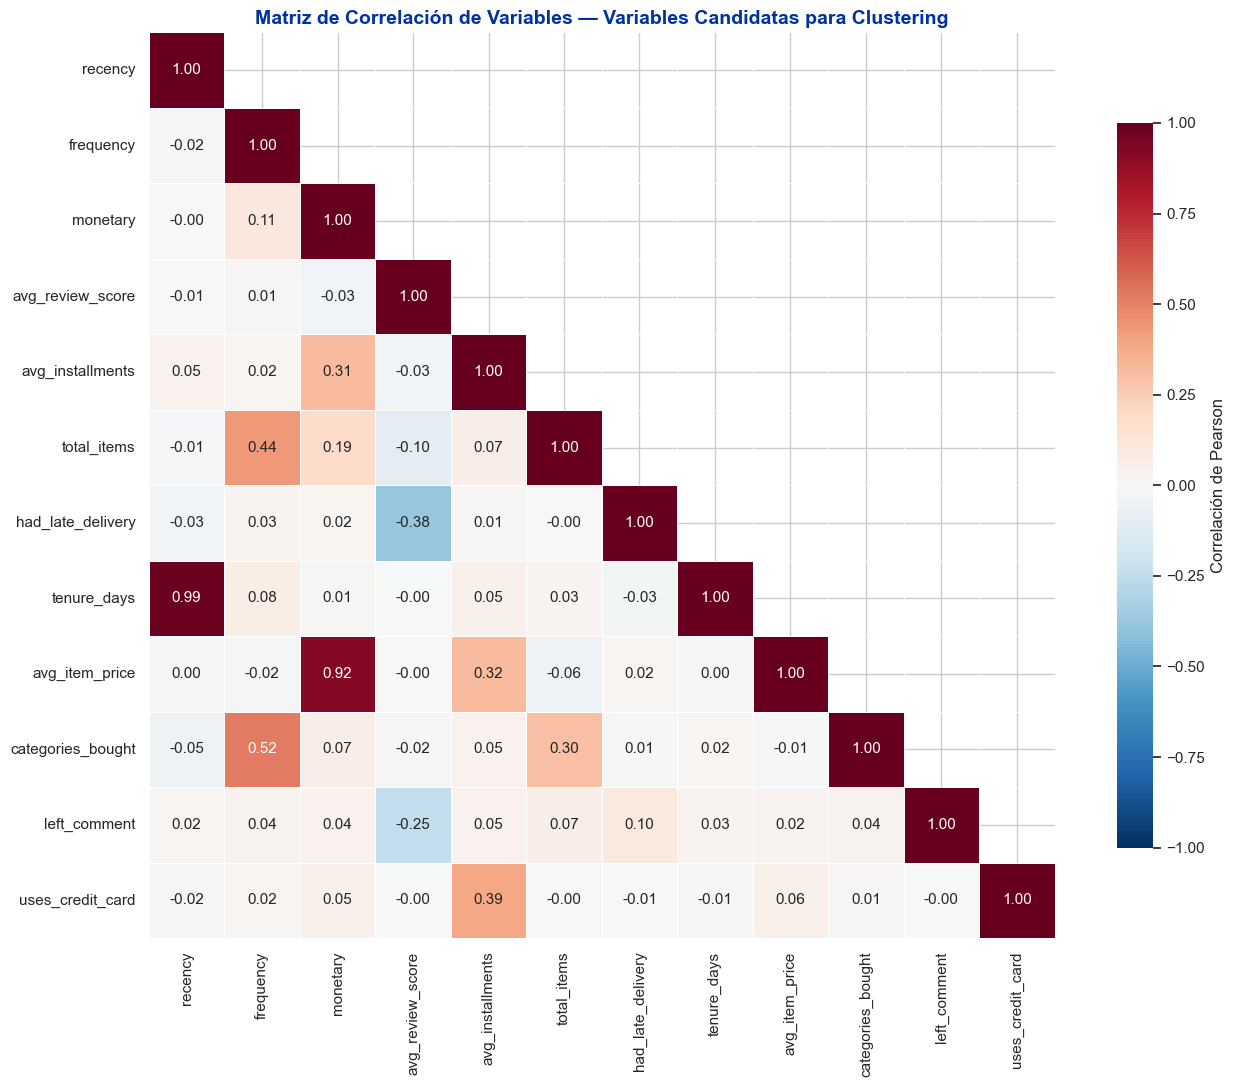


  CORRELACIONES ALTAS (|r| > 0.7):
  recency              ↔ tenure_days           r = +0.987
  monetary             ↔ avg_item_price        r = +0.918

 CORRELACIONES MODERADAS (0.4 < |r| < 0.7):
  frequency            ↔ total_items           r = +0.437
  frequency            ↔ categories_bought     r = +0.518


In [38]:
# --- Análisis de Correlación: detectar features redundantes ---
candidate_features = [
    'recency', 'frequency', 'monetary', 'avg_review_score',
    'avg_installments', 'total_items', 'had_late_delivery',
    'tenure_days', 'avg_item_price',
    # También verificar features calculadas pero aún no seleccionadas
    'categories_bought', 'left_comment', 'uses_credit_card'
]

corr_matrix = customer_360[candidate_features].corr()

# Mapa de calor
fig, ax = plt.subplots(figsize=(14, 11))
fig.set_facecolor('white')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de Correlación de Variables — Variables Candidatas para Clustering',
             fontsize=14, fontweight='bold', color='#0033a0')
plt.tight_layout()
plt.savefig('../outputs/03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Marcar correlaciones altas (|r| > 0.7)
print('\n  CORRELACIONES ALTAS (|r| > 0.7):')
print('=' * 60)
high_corr_found = False
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_found = True
            print(f'  {corr_matrix.index[i]:20s} ↔ {corr_matrix.columns[j]:20s}  r = {r:+.3f}')
if not high_corr_found:
    print('  Ninguna encontrada — todas las variables por debajo del umbral |0.7|')

# Correlaciones moderadas a tener en cuenta
print('\n CORRELACIONES MODERADAS (0.4 < |r| < 0.7):')
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if 0.4 < abs(r) <= 0.7:
            print(f'  {corr_matrix.index[i]:20s} ↔ {corr_matrix.columns[j]:20s}  r = {r:+.3f}')

In [39]:
# --- Análisis de Varianza y Poder Discriminativo ---
print(' ANÁLISIS DE VARIANZA Y DISTRIBUCIÓN DE VARIABLES')
print('=' * 85)
print(f'  {"Variable":22s} {"Media":>10s} {"Std":>10s} {"Único%":>10s} {"Cero%":>10s}  Evaluación')
print('-' * 85)

for feat in candidate_features:
    col = customer_360[feat]
    mean_val = col.mean()
    std_val = col.std()
    unique_pct = col.nunique() / len(col) * 100
    zero_pct = (col == 0).mean() * 100
    
    # Marcar problemas
    if unique_pct < 0.1:
        flag = '  Casi constante — bajo poder discriminativo'
    elif zero_pct > 90:
        flag = '  >90% ceros — dominada por un solo valor'
    elif std_val / (abs(mean_val) + 1e-10) < 0.1:
        flag = '  Baja varianza relativa'
    else:
        flag = 'OK'
    
    print(f'  {feat:22s} {mean_val:>10.2f} {std_val:>10.2f} {unique_pct:>9.2f}% {zero_pct:>9.1f}%  {flag}')

# Features binarias: verificar balance de clases
print('\n BALANCE DE CLASES EN VARIABLES BINARIAS:')
binary_feats = ['had_late_delivery', 'left_comment', 'uses_credit_card']
for feat in binary_feats:
    pct_1 = customer_360[feat].mean() * 100
    print(f'  {feat:22s}  {pct_1:5.1f}% positivo  /  {100-pct_1:5.1f}% negativo')

# Resumen de decisiones
print('\n' + '=' * 85)
print(' DECISIÓN DE SELECCIÓN DE VARIABLES:')
print('  Las variables con varianza cercana a cero o desbalance extremo de clases agregan ruido a K-Means')
print('  porque no aportan señal discriminativa mientras afectan los cálculos de distancia')
print('  por igual después de la estandarización.')
print('  Evaluaremos los resultados y descartaremos las variables señaladas a continuación.')

 ANÁLISIS DE VARIANZA Y DISTRIBUCIÓN DE VARIABLES
  Variable                    Media        Std     Único%      Cero%  Evaluación
-------------------------------------------------------------------------------------
  recency                    237.94     152.59      0.65%       0.0%  OK
  frequency                    1.03       0.21      0.01%       0.0%    Casi constante — bajo poder discriminativo
  monetary                   141.62     215.69      9.06%       0.0%  OK
  avg_review_score             4.16       1.28      0.03%       0.0%    Casi constante — bajo poder discriminativo
  avg_installments             2.90       2.68      0.09%       0.0%    Casi constante — bajo poder discriminativo
  total_items                  1.18       0.62      0.02%       0.0%    Casi constante — bajo poder discriminativo
  had_late_delivery            0.07       0.25      0.00%      93.0%    Casi constante — bajo poder discriminativo
  tenure_days                240.59     153.10      0.66%     

In [40]:
# --- Selección de features basada en análisis de correlación + varianza ---

# DECISIONES (basadas en datos):
#   ELIMINAR tenure_days      -> r=0.987 con recency (redundante: primera compra ≈ última compra para el 97%)
#   ELIMINAR avg_item_price   -> r=0.918 con monetary (redundante bajo dominancia de compra única)
#   ELIMINAR uses_credit_card -> 77% positivo, bajo poder discriminativo para clustering
#   ELIMINAR categories_bought-> casi constante (99% compró de 1 categoría)
#   ELIMINAR left_comment     -> señal incremental débil
#   MANTENER frequency        -> baja varianza pero crítica para detectar la minoría leal
#   MANTENER avg_installments -> señal de comportamiento de pago
#   MANTENER total_items      -> matiz de tamaño de carrito
#   NOTA: had_late_delivery se mantiene como CAPA DE RIESGO DE NEGOCIO, no como driver de clustering

CLUSTER_FEATURES = [
    'recency',
    'frequency',
    'monetary',
    'avg_review_score',
    'avg_installments',
    'total_items',
]

print(f'Selected {len(CLUSTER_FEATURES)} clustering features (behavior/value oriented):')
print('  recency, frequency, monetary, avg_review_score, avg_installments, total_items')
print('  had_late_delivery moved to post-cluster risk overlay')

X = customer_360[CLUSTER_FEATURES].copy()

# Transformación log para features muy sesgadas para reducir impacto de outliers
for col in ['monetary', 'total_items']:
    X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nClustering matrix: {X_scaled.shape[0]:,} customers x {X_scaled.shape[1]} features')
print(f'Features used in clustering: {CLUSTER_FEATURES}')

Selected 6 clustering features (behavior/value oriented):
  recency, frequency, monetary, avg_review_score, avg_installments, total_items
  had_late_delivery moved to post-cluster risk overlay

Clustering matrix: 93,358 customers x 6 features
Features used in clustering: ['recency', 'frequency', 'monetary', 'avg_review_score', 'avg_installments', 'total_items']


---
## 4. Selección de K: Óptimo Estadístico vs. Granularidad de Negocio

K=2: Inercia=71,299, Silueta=0.3360
K=3: Inercia=58,767, Silueta=0.3034
K=4: Inercia=49,472, Silueta=0.2947
K=5: Inercia=41,939, Silueta=0.2513
K=6: Inercia=36,033, Silueta=0.2691
K=7: Inercia=32,435, Silueta=0.2494
K=8: Inercia=30,711, Silueta=0.2544

Mejor K por silueta: 2 (silueta máx.=0.3360)
Elección de negocio: K=4 para mejor granularidad de campañas (retener/crecer/recuperar/reactivar).


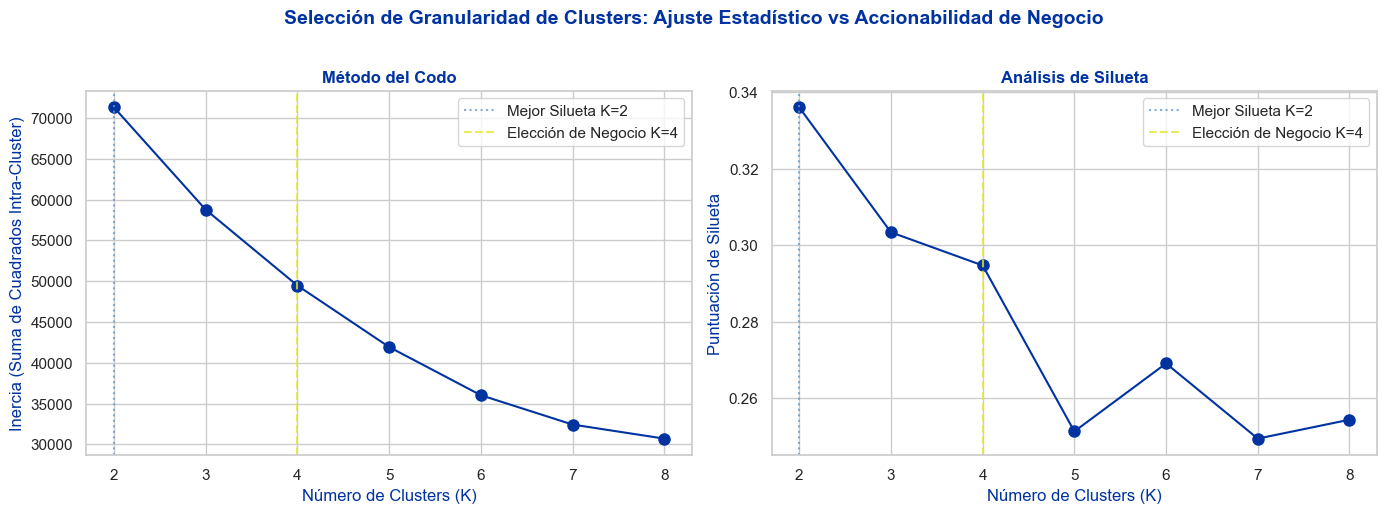

In [41]:
# Método del codo + Puntajes de silueta
K_range = range(2, 9)
inertias = []
silhouettes = []

np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=min(15000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f'K={k}: Inercia={km.inertia_:,.0f}, Silueta={sil:.4f}')

best_k_sil = K_range[int(np.argmax(silhouettes))]
print(f'\nMejor K por silueta: {best_k_sil} (silueta máx.={max(silhouettes):.4f})')
print('Elección de negocio: K=4 para mejor granularidad de campañas (retener/crecer/recuperar/reactivar).')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.set_facecolor('white')

axes[0].plot(K_range, inertias, 'o-', markersize=8, color=COLORS['primary'])
axes[0].set_xlabel('Número de Clusters (K)', color='#0033a0')
axes[0].set_ylabel('Inercia (Suma de Cuadrados Intra-Cluster)', color='#0033a0')
axes[0].set_title('Método del Codo', fontweight='bold', color='#0033a0')
axes[0].axvline(x=best_k_sil, color=COLORS['accent'], linestyle=':', alpha=0.8, label=f'Mejor Silueta K={best_k_sil}')
axes[0].axvline(x=4, color=COLORS['secondary'], linestyle='--', alpha=0.8, label='Elección de Negocio K=4')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'o-', markersize=8, color=COLORS['primary'])
axes[1].set_xlabel('Número de Clusters (K)', color='#0033a0')
axes[1].set_ylabel('Puntuación de Silueta', color='#0033a0')
axes[1].set_title('Análisis de Silueta', fontweight='bold', color='#0033a0')
axes[1].axvline(x=best_k_sil, color=COLORS['accent'], linestyle=':', alpha=0.8, label=f'Mejor Silueta K={best_k_sil}')
axes[1].axvline(x=4, color=COLORS['secondary'], linestyle='--', alpha=0.8, label='Elección de Negocio K=4')
axes[1].legend()

plt.suptitle('Selección de Granularidad de Clusters: Ajuste Estadístico vs Accionabilidad de Negocio', fontsize=14, fontweight='bold', y=1.02, color='#0033a0')
plt.tight_layout()
plt.savefig('../outputs/03_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

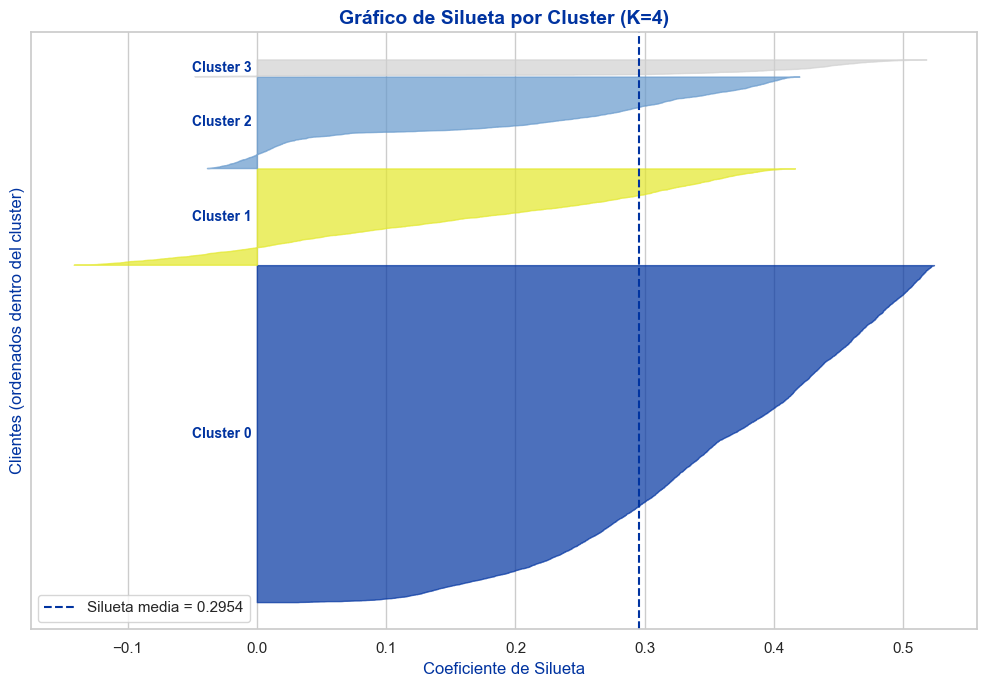


Puntuación de silueta para K=4 (muestra completa): 0.2954
Silueta media por cluster:
  Cluster 0: media=0.3584, mín=0.0306, n=9,334
  Cluster 1: media=0.1642, mín=-0.1417, n=2,668
  Cluster 2: media=0.1854, mín=-0.0386, n=2,533
  Cluster 3: media=0.3815, mín=-0.0483, n=465


In [42]:
# --- Gráfico de silueta por cluster para validación de K=4 ---

# Ajustar K=4 sobre la misma muestra usada para selección
km4 = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
labels_4 = km4.fit_predict(X_sample)
sil_vals = silhouette_samples(X_sample, labels_4)
sil_avg = silhouette_score(X_sample, labels_4)

fig, ax = plt.subplots(figsize=(10, 7))
fig.set_facecolor('white')
y_lower = 10
cluster_colors = ['#0033a0', '#e3e82a', '#6699cc', '#d0d0d0']

for i in range(4):
    cluster_sil = np.sort(sil_vals[labels_4 == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=cluster_colors[i], edgecolor=cluster_colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, f'Cluster {i}',
            fontweight='bold', fontsize=10, va='center', color='#0033a0')
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='#0033a0', linestyle='--', linewidth=1.5,
           label=f'Silueta media = {sil_avg:.4f}')
ax.set_xlabel('Coeficiente de Silueta', fontsize=12, color='#0033a0')
ax.set_ylabel('Clientes (ordenados dentro del cluster)', fontsize=12, color='#0033a0')
ax.set_title('Gráfico de Silueta por Cluster (K=4)', fontsize=14, fontweight='bold', color='#0033a0')
ax.set_yticks([])
ax.legend(loc='best', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/03_silhouette_per_cluster_k4.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPuntuación de silueta para K=4 (muestra completa): {sil_avg:.4f}')
print(f'Silueta media por cluster:')
for i in range(4):
    cluster_sil = sil_vals[labels_4 == i]
    print(f'  Cluster {i}: media={cluster_sil.mean():.4f}, '
          f'mín={cluster_sil.min():.4f}, n={len(cluster_sil):,}')

---
## 5. Clustering Final con K=4 (Segmentos Accionables para el Negocio)

In [43]:
# Fit final model on all data
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=300)
customer_360['cluster'] = kmeans.fit_predict(X_scaled)

print('Distribución de clusters (K=4):')
cluster_counts = customer_360['cluster'].value_counts().sort_index()
for c, n in cluster_counts.items():
    print(f'  Cluster {c}: {n:>6,} clientes ({n/len(customer_360)*100:>5.1f}%)')

print('\nNota de interpretación: K=2 separa grupos amplios mejor estadísticamente, pero K=4 proporciona acciones CRM más claras.')

Distribución de clusters (K=4):
  Cluster 0: 44,652 clientes ( 47.8%)
  Cluster 1: 16,588 clientes ( 17.8%)
  Cluster 2: 29,049 clientes ( 31.1%)
  Cluster 3:  3,069 clientes (  3.3%)

Nota de interpretación: K=2 separa grupos amplios mejor estadísticamente, pero K=4 proporciona acciones CRM más claras.


In [44]:
# --- Perfiles de clusters: centroides en escala original ---
PROFILE_FEATURES = CLUSTER_FEATURES + ['had_late_delivery']

cluster_profiles = customer_360.groupby('cluster')[PROFILE_FEATURES].agg(['mean', 'median']).round(2)
profiles_mean = customer_360.groupby('cluster')[PROFILE_FEATURES].mean().round(2)
profiles_mean.index.name = 'Cluster'

profiles_mean['count'] = customer_360.groupby('cluster').size()
profiles_mean['pct_repeat'] = customer_360.groupby('cluster')['frequency'].apply(lambda x: (x > 1).mean() * 100).round(1)
profiles_mean['pct_left_comment'] = customer_360.groupby('cluster')['left_comment'].mean().round(2) * 100

print('PERFILES DE CLUSTERS (Valores Medios)')
print('=' * 120)
print(profiles_mean.T.to_string())

PERFILES DE CLUSTERS (Valores Medios)
Cluster                   0         1         2        3
recency              133.65    241.33    398.17   220.36
frequency              1.00      1.00      1.00     2.02
monetary              96.26    319.69     94.82   282.14
avg_review_score       4.09      3.96      4.39     4.13
avg_installments       1.77      7.48      1.98     3.18
total_items            1.09      1.27      1.08     2.91
had_late_delivery      0.08      0.08      0.04     0.10
count              44652.00  16588.00  29049.00  3069.00
pct_repeat             0.00      0.00      0.00    91.30
pct_left_comment      39.00     46.00     39.00    52.00


In [45]:
# --- Asignar etiquetas de negocio + construir capa de riesgo ---

cluster_ranking = profiles_mean[['monetary', 'frequency', 'avg_review_score', 'recency']].copy()
cluster_ranking['loyalty_score'] = (
    cluster_ranking['monetary'] / cluster_ranking['monetary'].max() * 0.30 +
    cluster_ranking['frequency'] / cluster_ranking['frequency'].max() * 0.35 +
    cluster_ranking['avg_review_score'] / 5 * 0.20 +
    (1 - cluster_ranking['recency'] / cluster_ranking['recency'].max()) * 0.15
)

sorted_clusters = cluster_ranking['loyalty_score'].sort_values(ascending=False).index.tolist()

SEGMENT_LABELS = {}
SEGMENT_COLORS = {}
label_options = [
    ('Loyal Champions', '#0033a0'),
    ('Premium Buyers', '#e3e82a'),
    ('Mid-Value Buyers', '#6699cc'),
    ('Low-Engagement Buyers', '#d0d0d0')
]

for i, cluster_id in enumerate(sorted_clusters):
    SEGMENT_LABELS[cluster_id] = label_options[i][0]
    SEGMENT_COLORS[cluster_id] = label_options[i][1]

customer_360['segment'] = customer_360['cluster'].map(SEGMENT_LABELS)

# Capa de riesgo de servicio (independiente del clustering)
customer_360['service_risk_flag'] = ((customer_360['had_late_delivery'] == 1) | (customer_360['avg_review_score'] <= 3)).astype(int)

print('ASIGNACIÓN DE SEGMENTOS')
print('=' * 90)
for cluster_id in sorted_clusters:
    p = profiles_mean.loc[cluster_id]
    label = SEGMENT_LABELS[cluster_id]
    risk_rate = customer_360.loc[customer_360['cluster'] == cluster_id, 'service_risk_flag'].mean() * 100
    print(f'\nCluster {cluster_id} -> "{label}" ({p["count"]:,.0f} clientes)')
    print(f'  Recencia: {p["recency"]:.0f} días | Frecuencia: {p["frequency"]:.2f} | Monetario: R$ {p["monetary"]:.0f}')
    print(f'  Reseña Prom.: {p["avg_review_score"]:.2f} | Tasa Repetición: {p["pct_repeat"]:.1f}% | Riesgo Servicio: {risk_rate:.1f}%')

ASIGNACIÓN DE SEGMENTOS

Cluster 3 -> "Loyal Champions" (3,069 clientes)
  Recencia: 220 días | Frecuencia: 2.02 | Monetario: R$ 282
  Reseña Prom.: 4.13 | Tasa Repetición: 91.3% | Riesgo Servicio: 25.3%

Cluster 1 -> "Premium Buyers" (16,588 clientes)
  Recencia: 241 días | Frecuencia: 1.00 | Monetario: R$ 320
  Reseña Prom.: 3.96 | Tasa Repetición: 0.0% | Riesgo Servicio: 28.9%

Cluster 0 -> "Mid-Value Buyers" (44,652 clientes)
  Recencia: 134 días | Frecuencia: 1.00 | Monetario: R$ 96
  Reseña Prom.: 4.09 | Tasa Repetición: 0.0% | Riesgo Servicio: 25.1%

Cluster 2 -> "Low-Engagement Buyers" (29,049 clientes)
  Recencia: 398 días | Frecuencia: 1.00 | Monetario: R$ 95
  Reseña Prom.: 4.39 | Tasa Repetición: 0.0% | Riesgo Servicio: 16.0%


In [46]:
# --- Guardar resultados de segmentación para notebooks posteriores ---
export_cols = ['segment', 'cluster', 'service_risk_flag', 'recency', 'frequency', 
               'monetary', 'avg_review_score', 'avg_installments', 'total_items', 'had_late_delivery']
customer_360[export_cols].to_csv('../outputs/03_customer_segments.csv')
print(f'Saved {len(customer_360):,} customer segments to outputs/03_customer_segments.csv')
print(f'Segment distribution:\n{customer_360["segment"].value_counts().to_string()}')

Saved 93,358 customer segments to outputs/03_customer_segments.csv
Segment distribution:
segment
Mid-Value Buyers         44652
Low-Engagement Buyers    29049
Premium Buyers           16588
Loyal Champions           3069


---
## 6. Visualización — Diagnósticos de Segmentos de Alta Señal

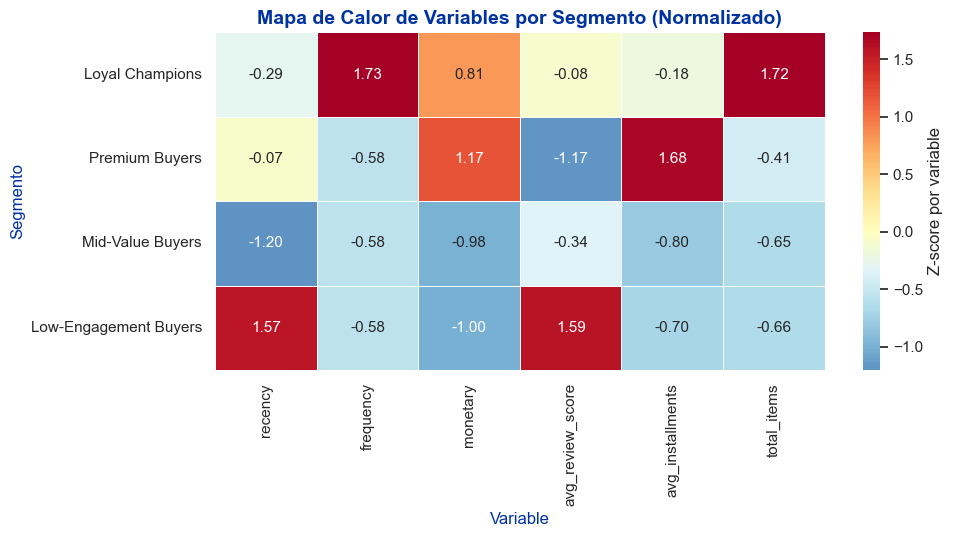

In [47]:
# --- Mapa de calor de perfiles de segmento (normalizado) ---

heatmap_features = ['recency', 'frequency', 'monetary', 'avg_review_score', 'avg_installments', 'total_items']
profile_table = profiles_mean.loc[sorted_clusters, heatmap_features].copy()

# Convertir a z-scores por feature para comparaciones justas entre features
profile_z = (profile_table - profile_table.mean()) / profile_table.std(ddof=0)
profile_z.index = [SEGMENT_LABELS[c] for c in profile_z.index]

fig = plt.figure(figsize=(10, 5.5))
fig.set_facecolor('white')
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, linewidths=0.5,
            cbar_kws={'label': 'Z-score por variable'})
plt.title('Mapa de Calor de Variables por Segmento (Normalizado)', fontsize=14, fontweight='bold', color='#0033a0')
plt.xlabel('Variable', color='#0033a0')
plt.ylabel('Segmento', color='#0033a0')
plt.tight_layout()
plt.savefig('../outputs/03_segment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

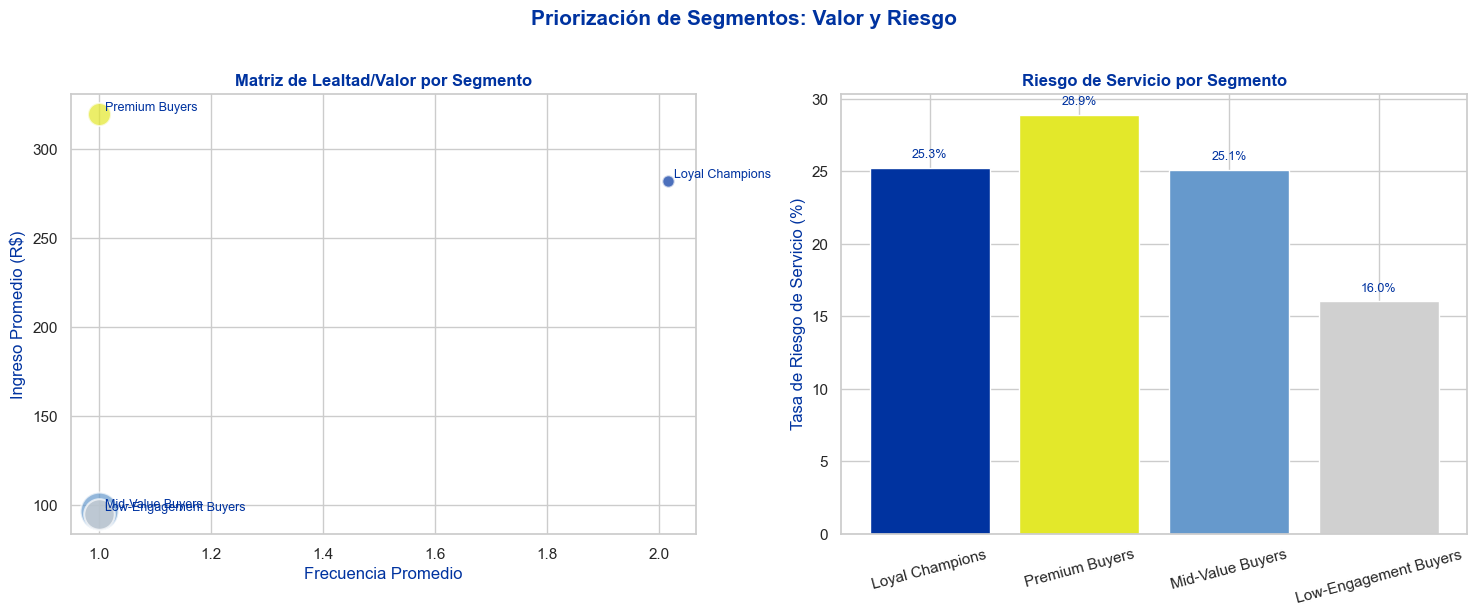

In [48]:
# --- Matriz de lealtad vs riesgo (nivel segmento) ---

segment_summary = customer_360.groupby('segment').agg(
    customers=('segment', 'size'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    risk_rate=('service_risk_flag', 'mean')
)

order = [SEGMENT_LABELS[c] for c in sorted_clusters]
segment_summary = segment_summary.loc[order]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.set_facecolor('white')

# Gráfico de burbujas: lealtad/valor vs riesgo
ax = axes[0]
for seg in order:
    row = segment_summary.loc[seg]
    color = next(SEGMENT_COLORS[c] for c in sorted_clusters if SEGMENT_LABELS[c] == seg)
    ax.scatter(row['avg_frequency'], row['avg_monetary'],
               s=max(80, row['customers'] / 60), color=color, alpha=0.7,
               edgecolor='white', linewidth=1.5)
    ax.text(row['avg_frequency'] + 0.01, row['avg_monetary'] + 2, seg, fontsize=9, color='#0033a0')

ax.set_xlabel('Frecuencia Promedio', color='#0033a0')
ax.set_ylabel('Ingreso Promedio (R$)', color='#0033a0')
ax.set_title('Matriz de Lealtad/Valor por Segmento', fontweight='bold', color='#0033a0')

# Gráfico de barras de tasa de riesgo
ax = axes[1]
risk_vals = (segment_summary['risk_rate'] * 100)
colors = [next(SEGMENT_COLORS[c] for c in sorted_clusters if SEGMENT_LABELS[c] == seg) for seg in order]
bars = ax.bar(order, risk_vals, color=colors, edgecolor='white')
for bar, val in zip(bars, risk_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.7, f'{val:.1f}%', ha='center', fontsize=9, color='#0033a0')
ax.set_ylabel('Tasa de Riesgo de Servicio (%)', color='#0033a0')
ax.set_title('Riesgo de Servicio por Segmento', fontweight='bold', color='#0033a0')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('Priorización de Segmentos: Valor y Riesgo', fontsize=15, fontweight='bold', y=1.02, color='#0033a0')
plt.tight_layout()
plt.savefig('../outputs/03_segment_value_risk.png', dpi=150, bbox_inches='tight')
plt.show()

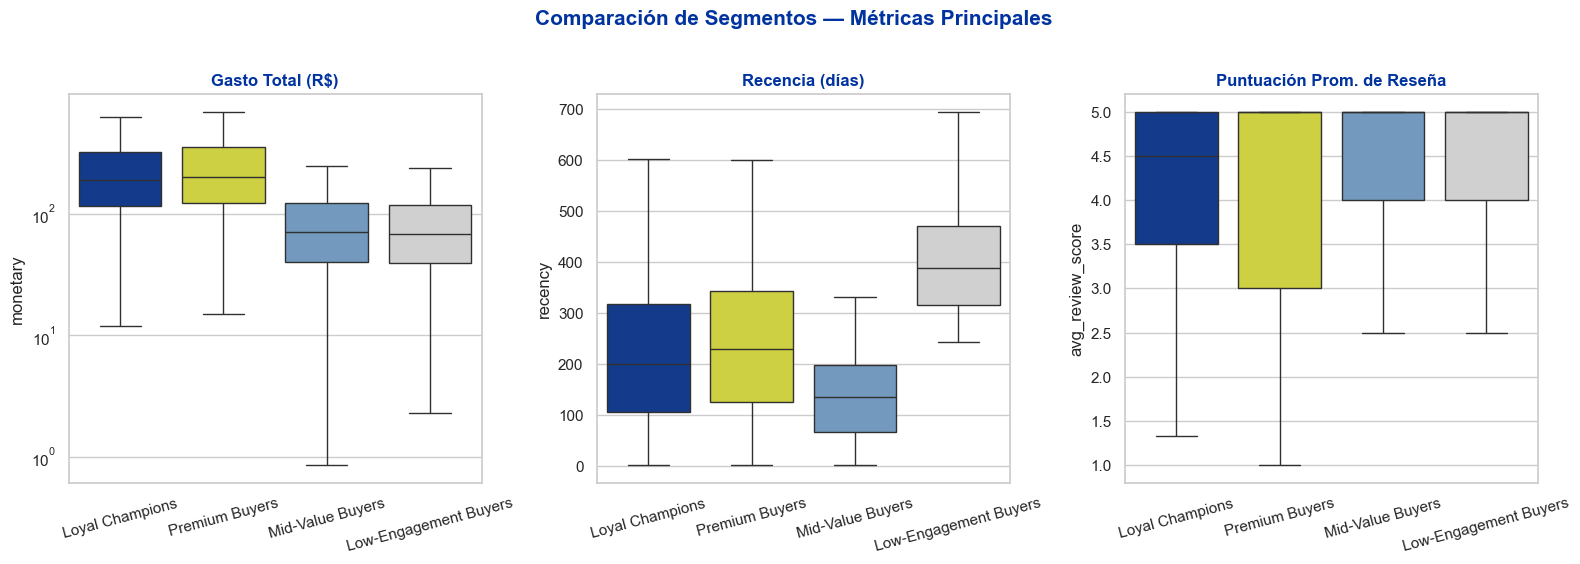

In [49]:
# --- Box plots: solo métricas clave (ruido reducido) ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.set_facecolor('white')
order = [SEGMENT_LABELS[c] for c in sorted_clusters]
palette = {SEGMENT_LABELS[c]: SEGMENT_COLORS[c] for c in sorted_clusters}

box_features = [
    ('monetary', 'Gasto Total (R$)', True),
    ('recency', 'Recencia (días)', False),
    ('avg_review_score', 'Puntuación Prom. de Reseña', False)
]

for ax, (feat, title, log_scale) in zip(axes, box_features):
    sns.boxplot(data=customer_360, x='segment', y=feat, order=order, palette=palette, ax=ax, showfliers=False)
    ax.set_title(title, fontweight='bold', color='#0033a0')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    if log_scale:
        ax.set_yscale('log')

plt.suptitle('Comparación de Segmentos — Métricas Principales', fontsize=15, fontweight='bold', y=1.02, color='#0033a0')
plt.tight_layout()
plt.savefig('../outputs/03_segment_boxplots_core.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Impacto en Ingresos por Segmento y Estrategia de Marketing Informada por Riesgo

In [50]:
# --- Contribución de ingresos por segmento ---
segment_revenue = customer_360.groupby('segment').agg(
    customers=('monetary', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_revenue=('monetary', 'mean'),
    median_revenue=('monetary', 'median'),
    avg_frequency=('frequency', 'mean'),
    avg_review=('avg_review_score', 'mean'),
    pct_late=('had_late_delivery', 'mean'),
    service_risk=('service_risk_flag', 'mean'),
    avg_recency=('recency', 'mean')
).round(2)

segment_revenue['revenue_share'] = (segment_revenue['total_revenue'] / segment_revenue['total_revenue'].sum() * 100).round(1)
segment_revenue['customer_share'] = (segment_revenue['customers'] / segment_revenue['customers'].sum() * 100).round(1)

seg_order = [SEGMENT_LABELS[c] for c in sorted_clusters]
segment_revenue = segment_revenue.loc[seg_order]

print('IMPACTO DE INGRESOS POR SEGMENTO')
print('=' * 110)
print(segment_revenue[['customers', 'customer_share', 'total_revenue', 'revenue_share',
                       'avg_revenue', 'avg_frequency', 'avg_review', 'service_risk']].to_string(
    formatters={
        'total_revenue': 'R$ {:,.0f}'.format,
        'avg_revenue': 'R$ {:,.0f}'.format,
        'customer_share': '{:.1f}%'.format,
        'revenue_share': '{:.1f}%'.format,
        'service_risk': '{:.1%}'.format
    }
))

IMPACTO DE INGRESOS POR SEGMENTO
                       customers customer_share total_revenue revenue_share avg_revenue  avg_frequency  avg_review service_risk
segment                                                                                                                        
Loyal Champions             3069           3.3%    R$ 865,873          6.5%      R$ 282           2.02        4.13        25.0%
Premium Buyers             16588          17.8%  R$ 5,302,940         40.1%      R$ 320           1.00        3.96        29.0%
Mid-Value Buyers           44652          47.8%  R$ 4,298,204         32.5%       R$ 96           1.00        4.09        25.0%
Low-Engagement Buyers      29049          31.1%  R$ 2,754,482         20.8%       R$ 95           1.00        4.39        16.0%


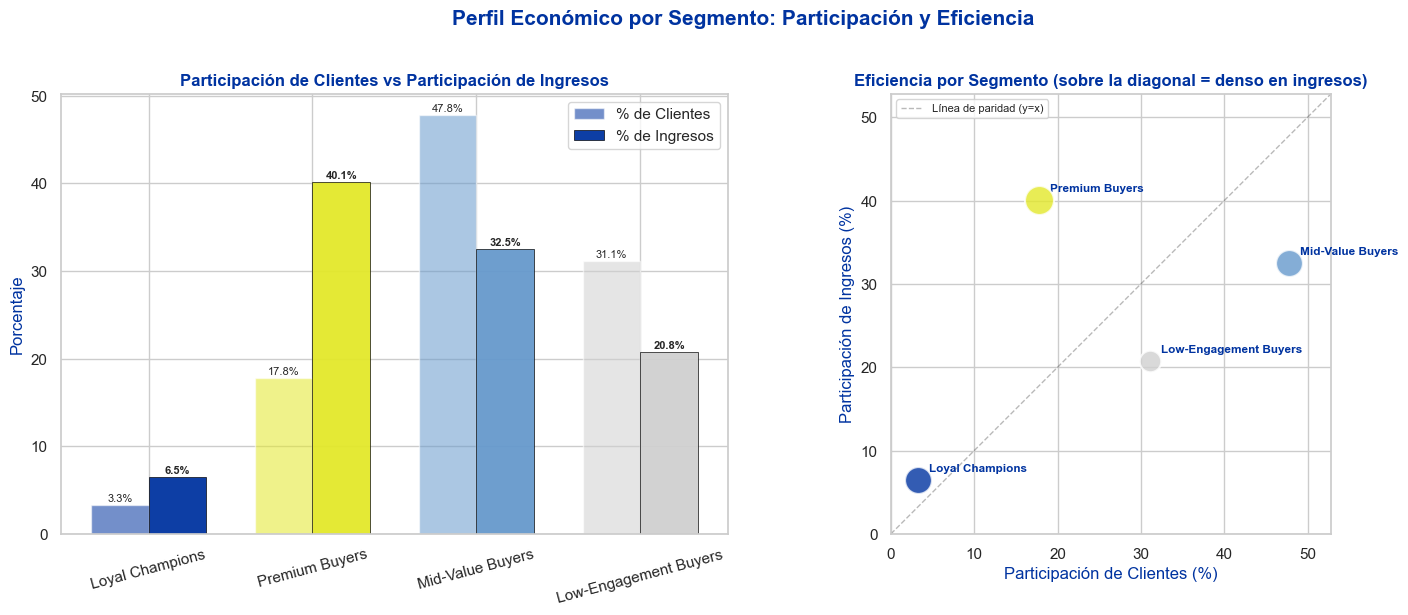

In [51]:
# --- Participación de ingresos vs clientes + scatter de eficiencia por segmento ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.set_facecolor('white')

# LEFT: Grouped bar chart — customer share vs revenue share
ax = axes[0]
x = np.arange(len(seg_order))
width = 0.35
bars1 = ax.bar(x - width/2, segment_revenue['customer_share'], width,
               label='% de Clientes', color=[SEGMENT_COLORS[c] for c in sorted_clusters], alpha=0.55)
bars2 = ax.bar(x + width/2, segment_revenue['revenue_share'], width,
               label='% de Ingresos', color=[SEGMENT_COLORS[c] for c in sorted_clusters], alpha=0.95,
               edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(seg_order, rotation=15)
ax.set_ylabel('Porcentaje', color='#0033a0')
ax.set_title('Participación de Clientes vs Participación de Ingresos', fontweight='bold', color='#0033a0')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

# DERECHA: Scatter — eficiencia del segmento (% clientes vs % ingresos, tamaño por riesgo)
ax = axes[1]
max_lim = max(segment_revenue['customer_share'].max(), segment_revenue['revenue_share'].max()) + 5
ax.plot([0, max_lim], [0, max_lim], 'k--', alpha=0.3, linewidth=1, label='Línea de paridad (y=x)')

for seg in seg_order:
    row = segment_revenue.loc[seg]
    color = next(SEGMENT_COLORS[c] for c in sorted_clusters if SEGMENT_LABELS[c] == seg)
    risk_pct = row['service_risk'] * 100
    size = max(80, risk_pct * 15)
    ax.scatter(row['customer_share'], row['revenue_share'],
               s=size, color=color, alpha=0.8, edgecolor='white', linewidth=1.5, zorder=5)
    ax.annotate(seg, (row['customer_share'], row['revenue_share']),
                textcoords='offset points', xytext=(8, 6), fontsize=8.5, fontweight='bold', color='#0033a0')

ax.set_xlabel('Participación de Clientes (%)', color='#0033a0')
ax.set_ylabel('Participación de Ingresos (%)', color='#0033a0')
ax.set_title('Eficiencia por Segmento (sobre la diagonal = denso en ingresos)', fontweight='bold', color='#0033a0')
ax.set_xlim(0, max_lim)
ax.set_ylim(0, max_lim)
ax.legend(fontsize=8)
ax.set_aspect('equal')

plt.suptitle('Perfil Económico por Segmento: Participación y Eficiencia', fontsize=15, fontweight='bold', y=1.02, color='#0033a0')
plt.tight_layout()
plt.savefig('../outputs/03_segment_revenue_risk.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# --- Plan de Acción de Marketing por Segmento (basado en datos) ---
from IPython.display import display, Markdown

rows = []
for seg in seg_order:
    sr = segment_revenue.loc[seg]
    cluster_id = next(c for c in sorted_clusters if SEGMENT_LABELS[c] == seg)
    pm = profiles_mean.loc[cluster_id]
    risk_pct = sr['service_risk'] * 100

    if seg == 'Loyal Champions':
        tactics = (
            f"Promedio de {pm['frequency']:.1f} compras y R\${sr['avg_revenue']:,.0f} de gasto. "
            f"Programa VIP con acceso anticipado y ofertas exclusivas. "
            f"Venta cruzada hacia categorías adyacentes a su historial de compras. "
            f"Programa de referidos aprovechando su alta satisfacción (reseña prom. {pm['avg_review_score']:.1f}/5)."
        )
        objective = "Retener y expandir"
        kpi = "Tasa de recompra, LTV, ingresos por referidos"
    elif seg == 'Premium Buyers':
        tactics = (
            f"Ticket alto (R\${sr['avg_revenue']:,.0f} prom.) pero una sola compra. "
            f"Email personalizado de reposición dentro de los 30 días post-compra. "
            f"Retargeting por categoría basado en su primera compra. "
            f"Recencia de {pm['recency']:.0f} días — se necesita win-back urgente."
        )
        objective = "Convertir a 2da compra"
        kpi = "Tasa de conversión a 2do pedido"
    elif seg == 'Mid-Value Buyers':
        tactics = (
            f"Gasto moderado (R\${sr['avg_revenue']:,.0f} prom.). "
            f"Promoción de planes de cuotas (prom. {pm['avg_installments']:.1f} cuotas sugiere sensibilidad al precio). "
            f"Ofertas de paquetes para aumentar tamaño del carrito (prom. {pm['total_items']:.1f} ítems). "
            f"Nutrir con contenido educativo por categoría."
        )
        objective = "Nutrir engagement"
        kpi = "Crecimiento de ticket, incremento de recompra"
    else:  # Low-Engagement Buyers
        tactics = (
            f"Gasto bajo (R\${sr['avg_revenue']:,.0f} prom.) con mayor riesgo de servicio ({risk_pct:.0f}%). "
            f"Priorizar mensajes de recuperación para clientes con flag de riesgo. "
            f"Campañas automatizadas de win-back de bajo costo. "
            f"Probar sensibilidad a descuentos antes de escalar inversión."
        )
        objective = "Reactivación eficiente"
        kpi = "ROI de reactivación, recuperación de riesgo"

    rows.append(f"| **{seg}** | {objective} | {tactics} | {kpi} |")

table = """---
## 8. Plan de Acción de Marketing por Segmento

| Segmento | Objetivo Principal | Tácticas Clave (basadas en datos) | KPI Foco |
|---|---|---|---|
""" + "\n".join(rows) + """

**Regla de Capa de Riesgo:** Dentro de cada segmento, priorizar a los clientes con `service_risk_flag = 1` para mensajes de recuperación y soporte proactivo."""

display(Markdown(table))

---
## 8. Plan de Acción de Marketing por Segmento

| Segmento | Objetivo Principal | Tácticas Clave (basadas en datos) | KPI Foco |
|---|---|---|---|
| **Loyal Champions** | Retener y expandir | Promedio de 2.0 compras y R\$282 de gasto. Programa VIP con acceso anticipado y ofertas exclusivas. Venta cruzada hacia categorías adyacentes a su historial de compras. Programa de referidos aprovechando su alta satisfacción (reseña prom. 4.1/5). | Tasa de recompra, LTV, ingresos por referidos |
| **Premium Buyers** | Convertir a 2da compra | Ticket alto (R\$320 prom.) pero una sola compra. Email personalizado de reposición dentro de los 30 días post-compra. Retargeting por categoría basado en su primera compra. Recencia de 241 días — se necesita win-back urgente. | Tasa de conversión a 2do pedido |
| **Mid-Value Buyers** | Nutrir engagement | Gasto moderado (R\$96 prom.). Promoción de planes de cuotas (prom. 1.8 cuotas sugiere sensibilidad al precio). Ofertas de paquetes para aumentar tamaño del carrito (prom. 1.1 ítems). Nutrir con contenido educativo por categoría. | Crecimiento de ticket, incremento de recompra |
| **Low-Engagement Buyers** | Reactivación eficiente | Gasto bajo (R\$95 prom.) con mayor riesgo de servicio (16%). Priorizar mensajes de recuperación para clientes con flag de riesgo. Campañas automatizadas de win-back de bajo costo. Probar sensibilidad a descuentos antes de escalar inversión. | ROI de reactivación, recuperación de riesgo |

**Regla de Capa de Riesgo:** Dentro de cada segmento, priorizar a los clientes con `service_risk_flag = 1` para mensajes de recuperación y soporte proactivo.

---
## 9. Hallazgos Clave y Resumen Ejecutivo

### Lo que validamos
- La realidad de los datos es extrema: aproximadamente **97% de compradores únicos**.
- Una segmentación pura de lealtad es difícil sin enriquecimiento conductual.
- Los diagnósticos de correlación/varianza respaldan la reducción de variables ruidosas o redundantes.

### Decisión de modelado
- **Mejor separación estadística:** `K=2` por silhouette.
- **Modelo operativo elegido:** `K=4` para accionabilidad a nivel de campaña.
- Este trade-off es explícito y orientado al negocio, no oculto.

### Lógica de segmentos
- El clustering captura **valor y propensión a la lealtad**.
- `had_late_delivery` se trata como una **capa de riesgo post-cluster**, evitando que los incidentes de servicio dominen la segmentación core de lealtad.

### Traducción de negocio
- Los segmentos ahora se mapean directamente a acciones de CRM: retener, convertir, nutrir y reactivar.
- Los gráficos de participación en ingresos + capa de riesgo hacen visible la priorización para stakeholders no técnicos.

### Notas metodológicas
- K-Means con variables estandarizadas y transformación logarítmica para señales monetarias sesgadas.
- Pipeline de variables: 12 candidatas → 6 variables de clustering + 1 variable de capa de riesgo.
- La nomenclatura de segmentos refleja la realidad conductual de este dataset (muchos compradores únicos, pequeña minoría leal).

### Sobre la factibilidad del modelado de churn

Los modelos tradicionales de churn requieren comportamiento de compra recurrente para definir un evento de abandono (ej., "cliente que compró al menos dos veces y luego dejó de comprar"). Con aproximadamente el 97% de los clientes realizando una sola compra, no existe señal conductual suficiente para entrenar un clasificador de churn significativo — el dataset carece de los patrones longitudinales de compra de los que dependen los modelos de churn. **Supuesto explícito:** Utilizamos el `service_risk_flag` (entrega tardía o puntaje de reseña bajo) como proxy práctico para la identificación de riesgo de abandono. Los clientes marcados con riesgo de servicio son aquellos con mayor probabilidad de haber tenido una experiencia negativa que impediría futuro engagement. Esto no es un modelo predictivo de churn sino una heurística de priorización basada en riesgo que permite acciones de recuperación focalizadas dentro de cada segmento.